In [6]:
# Descargando las dependencias 
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
# Cargando y realizando una copia del Dataset (from LR,SVC)
df_lr_svc = pd.read_csv("credit_risk_dataset.csv")
df_lr_svc_copy = df_lr_svc.copy()

# Cargando y realizando una copia del Dataset (from RFC,XGBC)
df_rf = pd.read_csv("credit_risk_dataset.csv")
df_rf_copy = df_lr_svc.copy()

### Intuiciones del Dataset (LR,SVC,RFC,XGBC)

In [24]:
# Visualización el dataset
df_lr_svc_copy.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [15]:
# Comprobando su shape
df_lr_svc_copy.shape

(32581, 12)

In [16]:
df_lr_svc_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [17]:
df_lr_svc_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [18]:
df_lr_svc_copy.isnull().sum().any()

np.True_

In [19]:
# Verificando que columnas y cuantos, valores faltante tienen
df_lr_svc_copy.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

**Verificando cuantos valores únicos tienen las variables categoricas**

In [36]:
df_lr_svc_copy["person_home_ownership"].value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

In [31]:
df_lr_svc_copy["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [33]:
df_lr_svc_copy["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

In [32]:
df_lr_svc_copy["loan_grade"].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

**Visualización de los valores nulos**

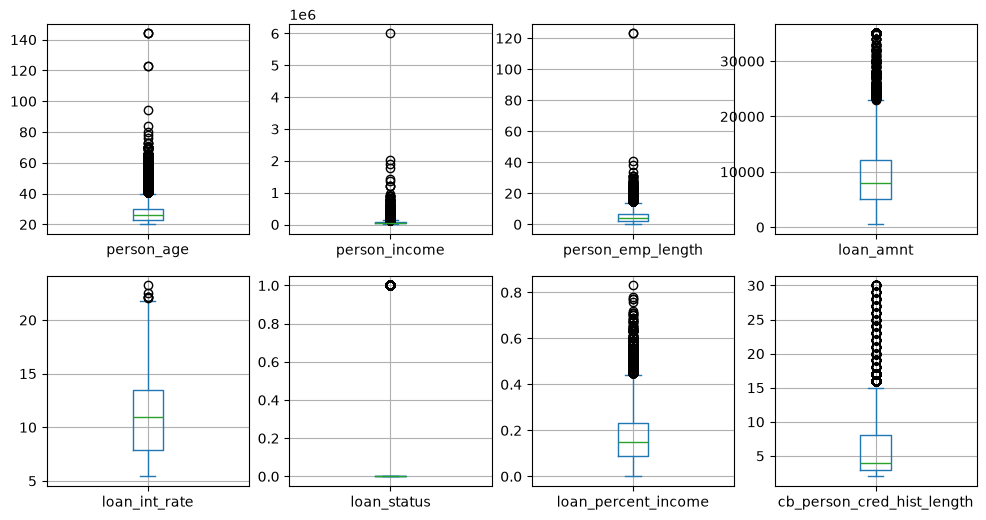

In [3]:
df_numeric = df_lr_svc_copy.select_dtypes(include=[float, int])
df_numeric.plot(kind='box', grid=True, subplots=True, layout=(2, 4), figsize=(12, 6))
plt.ticklabel_format()
plt.show()

### Limpieza de valores nulos y separación en sub conjuntos

In [3]:
# Limpiando los Dataset de los valores nulos
df_lr_svc_copy_clean = df_lr_svc_copy.dropna()
df_rf_copy_clean = df_rf_copy.dropna()

In [4]:
# Separación de las variables de entrada y salida (from LR,SVC)
x_lr = df_lr_svc_copy_clean.drop(columns=["loan_status"])
y_lr = df_lr_svc_copy_clean["loan_status"].copy()

# Separación de las variables de entrada y salida (from RFC,XGBC)
x_rf = df_rf_copy_clean.drop(columns=["loan_status"])
y_rf = df_rf_copy_clean["loan_status"].copy()

In [5]:
# Creando los sub conjuntos para los modelos LR,SVC
x_train_lr, x_mod_lr, y_train_lr, y_mod_lr = train_test_split(x_lr, y_lr, test_size=0.2, random_state=42)
x_test_lr, x_val_lr, y_test_lr, y_val_lr = train_test_split(x_mod_lr, y_mod_lr, test_size=0.5, random_state=42)

# Creando los sub conjuntos para los modelos RFC,XGBC
x_train_rf, x_mod_rf, y_train_rf, y_mod_rf = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42)
x_test_rf, x_val_rf, y_test_rf, y_val_rf = train_test_split(x_mod_rf, y_mod_rf, test_size=0.5, random_state=42)

In [9]:
print(df_lr_svc_copy.shape)
print(df_lr_svc_copy_clean.shape)

(32581, 12)
(28638, 12)


### Pipelines y preprocesamiento de los datos

**ColumnTransformer (from LR, SVC)**


In [19]:
# Definiendo las variables de entrada para su preprocesamiento
num_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
cat_cols = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]
ord_cols = ["loan_grade"]

# Pipeline para aplicar solo PCA
pipeline_pca = Pipeline(
    steps = [
        ("num", RobustScaler()),
        ("pca", PCA(n_components=0.95))
    ]
)

# Definiendo el orden explícito para ordinal
ord_categoria = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]

# Definiendo ColumnTransformer
preprocessor_lr = ColumnTransformer(
    transformers = [
        ("num", pipeline_pca, num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols),
        ("ord", OrdinalEncoder(categories=ord_categoria), ord_cols)
    ]
)

**Pipeline from Logistic Regression**

In [21]:
# Pipeline of Regresión Logistica
pipeline_lr = Pipeline(
    steps = [
        ("prep", preprocessor_lr),
        ("model", LogisticRegression())
    ]
)

**Pipeline and Tunning of SVC**

In [25]:
# Pipeline of SVC 
pipeline_svc = Pipeline(
    steps = [
        ("prep", preprocessor_lr),
        ("model", SVC())
    ]
)

# Definiendo los hiperparámetros y valores a buscar
param_grid_svc = [
    {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf"],
        "model__gamma": ["scale", "auto", 0.01, 0.1, 1]
    },
    {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear"]
    }
]

# GridSearch of SVC
grid_svc = GridSearchCV(
    estimator = pipeline_svc,
    param_grid = param_grid_svc,
    cv = 5,
    scoring = "f1",
    n_jobs = -1,
    verbose = 1
)

### Entrenamiento de los modelos 

**Run Pipeline Logistic Regression**

In [22]:
# Tomando el tiempo de entrenamiento del modelo
start_train_lr = time.time()
pipeline_lr.fit(x_train_lr, y_train_lr) # Entrenamiento del modelo LR
end_train_lr = time.time()

In [23]:
# Tiempo que se tardo el modelo (LR), en entrenarse 
time_lr = end_train_lr - start_train_lr
print(f"El tiempo de entrenamiento de LR, fue de {time_lr:.4f}")

El tiempo de entrenamiento de LR, fue de 0.2275


**Run GridSearch and Pipeline SVC**

In [26]:
# Tomando el tiempo de entrenamiento del modelo
start_train_svc = time.time()
grid_svc.fit(x_train_lr, y_train_lr) # Entrenamiento del modelo SVC 
end_train_svc = time.time()

Fitting 5 folds for each of 19 candidates, totalling 95 fits


In [27]:
# Tiempo que se tardo el modelo (SVC), en entrenarse
time_svc = end_train_svc - start_train_svc
print(f"El tiempo de entrenamiento de SVC, fue de {time_svc:.4f}")

El tiempo de entrenamiento de SVC, fue de 1050.9378
